# Deutsch Algorithm

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualization Function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=False)

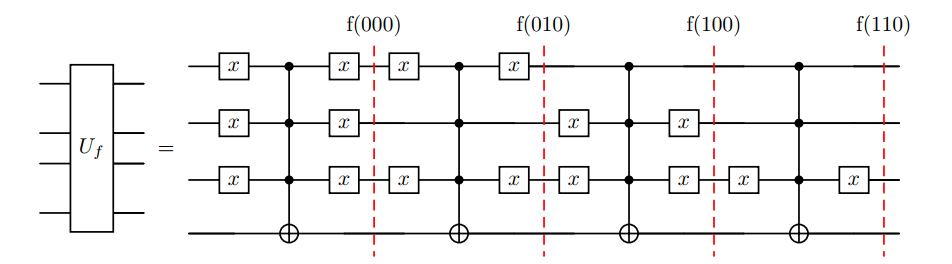

In [9]:
# create the quantum circuit
qc = QuantumCircuit(4, 3)

# first step
qc.x(-1)
qc.barrier()

# second step
qc.h(range(4))
qc.barrier()

# third step- Applying the oracle Uf
# 1st
qc.x(range(3))
qc.mcx([0,1,2],3)
qc.x(range(3))
qc.barrier()


#2nd
qc.x(0)
qc.x(2)
qc.mcx([0,1,2],3)
qc.x(0)
qc.x(2)
qc.barrier()

# 3rd
qc.x(1)
qc.x(2)
qc.mcx([0,1,2],3)
qc.x(1)
qc.x(2)
qc.barrier()

# 4th
qc.x(2)
qc.mcx([0,1,2],3)
qc.x(2)
qc.barrier()

qc.h(range(3))
qc.barrier()


for i in range(3):
    qc.measure(i,i)

qplot(qc)

░ ┌───┐ ░ ┌───┐     ┌───┐ ░ ┌───┐     ┌───┐ ░                 ░                 ░ ┌───┐ ░ ┌─┐      
q_0: ──────░─┤ H ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░────────■────────░────────■────────░─┤ H ├─░─┤M├──────
           ░ ├───┤ ░ ├───┤  │  ├───┤ ░ └───┘  │  └───┘ ░ ┌───┐  │  ┌───┐ ░        │        ░ ├───┤ ░ └╥┘┌─┐   
q_1: ──────░─┤ H ├─░─┤ X ├──■──┤ X ├─░────────■────────░─┤ X ├──■──┤ X ├─░────────■────────░─┤ H ├─░──╫─┤M├───
           ░ ├───┤ ░ ├───┤  │  ├───┤ ░ ┌───┐  │  ┌───┐ ░ ├───┤  │  ├───┤ ░ ┌───┐  │  ┌───┐ ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ──────░─┤ H ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─┤ H ├─░──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░ └───┘┌─┴─┐└───┘ ░ └───┘┌─┴─┐└───┘ ░ └───┘┌─┴─┐└───┘ ░ └───┘┌─┴─┐└───┘ ░ └───┘ ░  ║  ║ └╥┘
q_3: ┤ X ├─░─┤ H ├─░──────┤ X ├──────░──────┤ X ├──────░──────┤ X ├──────░──────┤ X ├──────░───────░──╫──╫──╫─
     └───┘ ░ └───┘ ░      └───┘      ░      └───┘      ░      └───┘      ░      └───┘      ░       ░  ║  ║  ║ 
c_0: ═════════════════════════════════════════════════════════════════════════════════════════════════╩══╬══╬═
                                                                                                         ║  ║ 
c_1: ════════════════════════════════════════════════════════════════════════════════════════════════════╩══╬═
                                                                                                            ║ 
c_2: ═══════════════════════════════════════════════════════════════════════════════════════════════════════╩═

In [10]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
counts

{'100': 1024}